# 📊 Loan Default Risk Analysis
### Practical Exam — Set C | Statistics, Probability & Linear Algebra

**Institute:** Red & White Skill Education
**Type:** Theory + Practical
**Duration:** 6 Hours
**Dataset:** `loan_applications.csv` (~5,000 records)

---

## 🎯 Objective

Explain key statistical concepts in theory, then apply Python-based statistical and probability analysis to evaluate **loan default risk** using a bank's customer application data.

## 📑 Problem Statement

A bank has shared a dataset of ~5,000 loan applications with fields: `Customer_ID`, `Age`, `Income`, `Loan_Amount`, `Credit_Score`, `Loan_Term`, and `Default_Status` (Yes/No). As a data analyst, the goal is to understand the spread of income and loan amounts, quantify the probability of default, check whether key variables follow known distributions, and represent customers as vectors to explore relationships between their financial attributes.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, norm

np.random.seed(42)
sns.set_style('whitegrid')


* First, I imported the libraries needed for this analysis.
* NumPy and Pandas handle the numbers and the data table, while Matplotlib and Seaborn handle the charts.
* SciPy's `stats` module gives me skewness, kurtosis, the Normal distribution, and probability-plot tools.
* I also set a random seed so any random sampling later stays reproducible.

In [ ]:
df = pd.read_csv('loan_applications.csv')
print("Shape:", df.shape)
df.head()


Shape: (5000, 7)


,Customer_ID,Age,Income,Loan_Amount,Credit_Score,Loan_Term,Default_Status
0,CUST00001,59,115481.02,57048.89,710,12,Yes
1,CUST00002,49,101893.30,67961.39,643,24,No
2,CUST00003,35,133046.12,20522.07,627,84,No
3,CUST00004,63,45634.97,6365.26,619,84,No
4,CUST00005,28,55995.75,16080.59,645,36,Yes


* Here I loaded the loan applications dataset with `pd.read_csv()`.
* Printing the shape confirms I have close to 5,000 customer records, matching what the problem statement described.
* `df.head()` shows me the first five rows, so I can visually confirm every field loaded correctly.
* This is always my first step before doing any calculations, just to make sure nothing is broken or misread.

In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Customer_ID     5000 non-null   str    
 1   Age             5000 non-null   int64  
 2   Income          5000 non-null   float64
 3   Loan_Amount     5000 non-null   float64
 4   Credit_Score    5000 non-null   int64  
 5   Loan_Term       5000 non-null   int64  
 6   Default_Status  5000 non-null   str    
dtypes: float64(2), int64(3), str(2)
memory usage: 273.6 KB


* I ran `df.info()` to check the technical health of the dataset.
* It confirms there are no missing values in any column, which matters a lot for statistics like mean and variance.
* It also shows me that Income, Loan_Amount, and Credit_Score are numeric, while Default_Status is text (Yes/No).
* This quick check saves me from running into errors later when I do numerical operations on the columns.

In [ ]:
df[['Age', 'Income', 'Loan_Amount', 'Credit_Score', 'Loan_Term']].describe()


,Age,Income,Loan_Amount,Credit_Score,Loan_Term
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.13460,53749.236190,21486.004412,649.764000,47.529600
std,12.89329,25986.853845,15260.588590,83.331631,31.823018
min,21.00000,15000.000000,5000.000000,317.000000,12.000000
25%,32.00000,35447.897500,10908.880000,595.000000,24.000000
50%,43.00000,48352.045000,17578.860000,649.000000,36.000000
75%,54.00000,66205.655000,27415.755000,706.000000,60.000000
max,65.00000,250000.000000,186823.000000,850.000000,120.000000


* Here I used `df.describe()` on the numeric columns to get a fast statistical overview.
* It shows me the mean, standard deviation, minimum, maximum, and quartiles for each column.
* I can already see Income and Loan_Amount have a wide range, which hints they might be right-skewed.
* This gives me a baseline understanding of the data before I calculate anything more specific.

### 🧮 Step 1 — Central Tendency & Dispersion

In [ ]:
income_mean = df['Income'].mean()
income_median = df['Income'].median()
income_mode = df['Income'].mode()[0]

loan_range = df['Loan_Amount'].max() - df['Loan_Amount'].min()
loan_variance = df['Loan_Amount'].var()
loan_std = df['Loan_Amount'].std()

print(f"Income -> Mean: {income_mean:,.2f}, Median: {income_median:,.2f}, Mode: {income_mode:,.2f}")
print(f"Loan_Amount -> Range: {loan_range:,.2f}, Variance: {loan_variance:,.2f}, Std Dev: {loan_std:,.2f}")


Income -> Mean: 53,749.24, Median: 48,352.04, Mode: 15,000.00
Loan_Amount -> Range: 181,823.00, Variance: 232,885,564.11, Std Dev: 15,260.59


* Here I calculated the mean, median, and mode of Income using Pandas' built-in `.mean()`, `.median()`, and `.mode()` methods.
* Since the mean is noticeably higher than the median, that's already a sign Income is right-skewed, pulled up by a smaller number of high earners.
* For Loan_Amount, I calculated the range (max minus min), the variance, and the standard deviation to measure how spread out loan sizes are.
* A large standard deviation relative to the mean tells me customers are taking out very different loan sizes, not clustering around one typical amount.

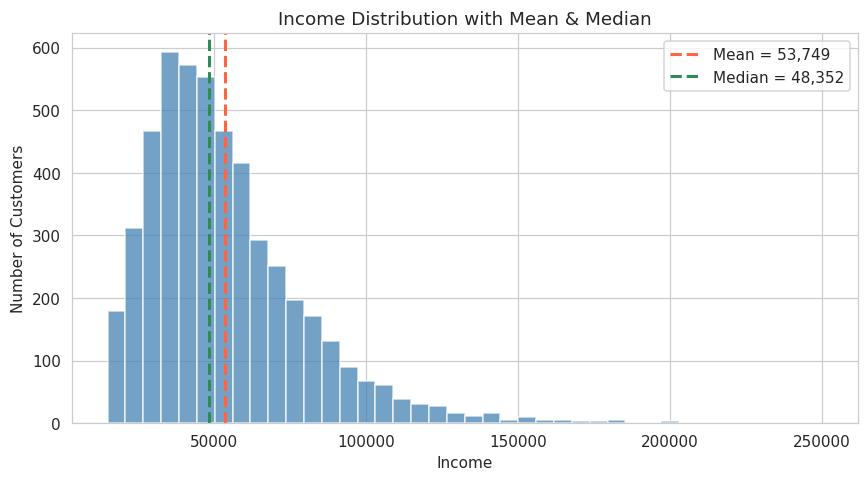

In [ ]:
plt.figure(figsize=(8, 4.5))
plt.hist(df['Income'], bins=40, color='steelblue', alpha=0.75)
plt.axvline(income_mean, color='tomato', linestyle='--', linewidth=2, label=f'Mean = {income_mean:,.0f}')
plt.axvline(income_median, color='seagreen', linestyle='--', linewidth=2, label=f'Median = {income_median:,.0f}')
plt.title('Income Distribution with Mean & Median')
plt.xlabel('Income')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation:** The long right tail and the gap between the mean (dashed red) and median (dashed green) confirm Income is right-skewed — most customers earn a moderate amount, while a smaller group of high earners stretches the average upward. This is exactly why median is often the more honest "typical income" figure to report.

### 🎲 Step 2 — Probability & Events

In [ ]:
p_default = (df['Default_Status'] == 'Yes').mean()
print(f"P(Default) = {p_default:.3f}  ->  {p_default*100:.1f}% of customers defaulted")


P(Default) = 0.172  ->  17.2% of customers defaulted


* Here I calculated the overall probability of default simply by finding what fraction of all customers have `Default_Status == 'Yes'`.
* This is an empirical probability — calculated directly from the observed data, not assumed in advance.
* It gives me a baseline default rate to compare against once I start splitting customers into subgroups.
* This single number becomes the benchmark for judging whether a subgroup (like low credit scores) is riskier than average.

In [ ]:
df['Credit_Score_Band'] = pd.cut(
    df['Credit_Score'],
    bins=[299, 599, 699, 799, 850],
    labels=['<600', '600-699', '700-799', '800+']
)

contingency = pd.crosstab(df['Credit_Score_Band'], df['Default_Status'])
contingency


Default_Status,No,Yes
Credit_Score_Band,,
<600,883,460
600-699,1961,317
700-799,1126,76
800+,169,8


* In this cell, I first grouped the continuous `Credit_Score` column into readable bands using `pd.cut()`.
* Then I built a contingency table with `pd.crosstab()`, which cross-tabulates every combination of credit score band and default status into a count.
* Each cell tells me exactly how many customers fall into that specific band *and* that specific outcome.
* This table is the raw material behind every conditional probability I calculate next.

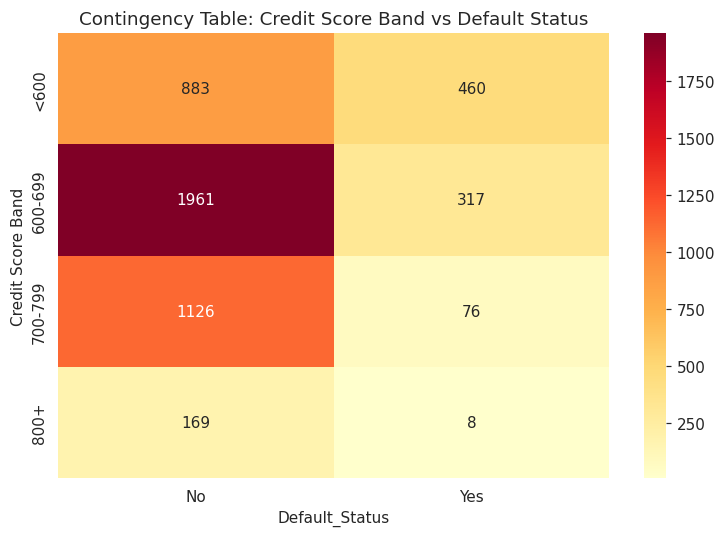

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(contingency, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Contingency Table: Credit Score Band vs Default Status')
plt.ylabel('Credit Score Band')
plt.tight_layout()
plt.show()


**Interpretation:** Darker cells in the "Yes" column for lower credit score bands would indicate more defaults concentrated among riskier applicants. Reading across each row shows how the balance between "Yes" and "No" shifts as credit score improves — this is the visual version of the conditional probability calculated next.

In [ ]:
low_credit = df[df['Credit_Score'] < 600]
p_default_given_low_credit = (low_credit['Default_Status'] == 'Yes').mean()

print(f"P(Default | Credit_Score < 600) = {p_default_given_low_credit:.3f}  ->  {p_default_given_low_credit*100:.1f}%")
print(f"Compare to overall P(Default) = {p_default:.3f}  ->  {p_default*100:.1f}%")


P(Default | Credit_Score < 600) = 0.343  ->  34.3%
Compare to overall P(Default) = 0.172  ->  17.2%


* Here I filtered the dataset down to only customers with a credit score below 600.
* Within just that subgroup, I calculated the same default probability as before — this is the conditional probability `P(Default | Credit_Score < 600)`.
* Comparing it to the overall default probability from earlier shows exactly how much riskier this subgroup really is.
* This kind of comparison is exactly what a bank would use to justify charging higher interest or requiring extra checks for low credit score applicants.

### 📈 Step 3 — Distributions & Visualization

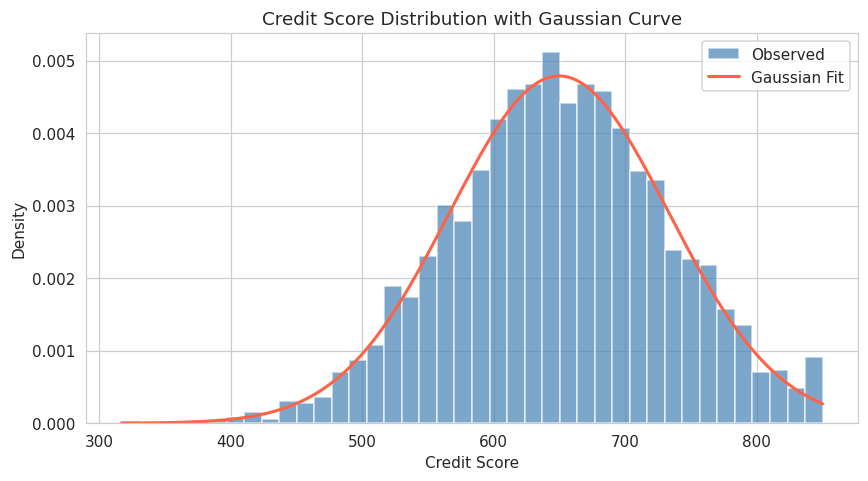

In [ ]:
mu, sigma = df['Credit_Score'].mean(), df['Credit_Score'].std()
x = np.linspace(df['Credit_Score'].min(), df['Credit_Score'].max(), 200)

plt.figure(figsize=(8, 4.5))
plt.hist(df['Credit_Score'], bins=40, density=True, color='steelblue', alpha=0.7, label='Observed')
plt.plot(x, norm.pdf(x, mu, sigma), color='tomato', lw=2, label='Gaussian Fit')
plt.title('Credit Score Distribution with Gaussian Curve')
plt.xlabel('Credit Score')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()


* Here I calculated the mean and standard deviation of Credit_Score, then used them to draw a theoretical Normal (Gaussian) curve on top of the real histogram.
* `density=True` scales the histogram so it can be directly compared to the smooth Gaussian curve, since both now represent probability density.
* If the red curve closely hugs the blue bars, that's evidence Credit_Score behaves like a Normal distribution.
* Credit scores are often designed by scoring agencies to be roughly Normal, so this is a good sanity check on the dataset.

In [ ]:
loan_skew = skew(df['Loan_Amount'])
loan_kurt = kurtosis(df['Loan_Amount'])

print(f"Skewness of Loan_Amount: {loan_skew:.3f}")
print(f"Kurtosis of Loan_Amount: {loan_kurt:.3f}")


Skewness of Loan_Amount: 2.161
Kurtosis of Loan_Amount: 8.644


* Here I calculated skewness, which tells me whether Loan_Amount leans toward small or large values, and kurtosis, which tells me how heavy the tails are compared to a Normal distribution.
* A positive skewness value confirms what I already suspected — most loans are small to moderate, with a smaller number of very large loans pulling the tail to the right.
* Kurtosis above zero would mean more extreme values (very small or very large loans) than a Normal distribution would predict.
* Both numbers back up visually what the earlier histogram of loan spread already hinted at.

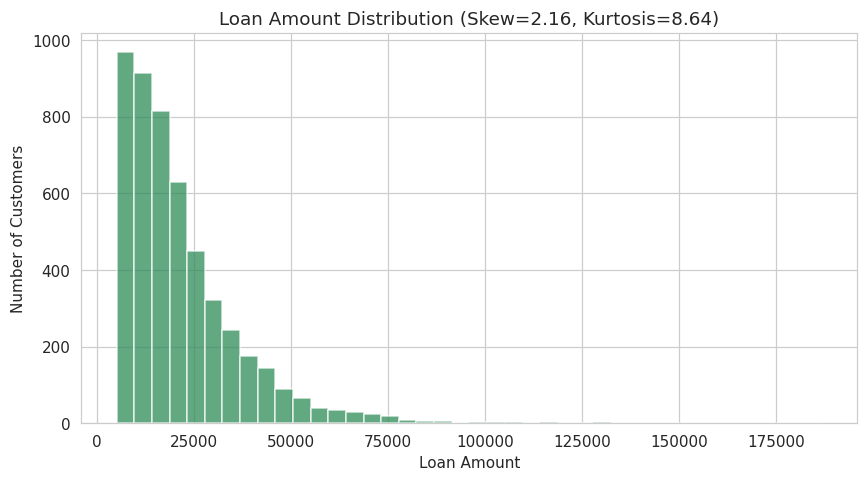

In [ ]:
plt.figure(figsize=(8, 4.5))
plt.hist(df['Loan_Amount'], bins=40, color='seagreen', alpha=0.75)
plt.title(f'Loan Amount Distribution (Skew={loan_skew:.2f}, Kurtosis={loan_kurt:.2f})')
plt.xlabel('Loan Amount')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


**Interpretation:** The long right tail visually confirms the positive skewness calculated above — a large group of customers take smaller loans, while a limited number take out much larger ones, stretching the distribution rightward rather than keeping it symmetric.

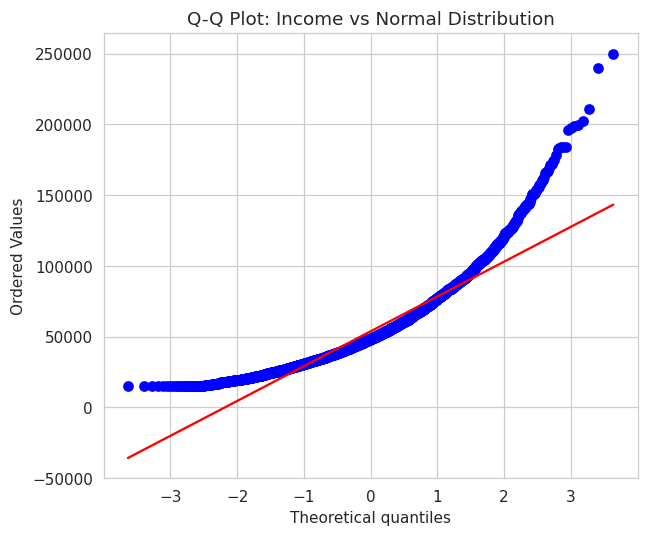

In [ ]:
plt.figure(figsize=(6, 5))
stats.probplot(df['Income'], dist='norm', plot=plt)
plt.title('Q-Q Plot: Income vs Normal Distribution')
plt.tight_layout()
plt.show()


* Here I used a Q-Q plot to check whether Income follows a Normal distribution.
* Each point compares an actual income value to what a Normal distribution would predict at that same percentile.
* Points curving away from the straight reference line, especially at the upper end, confirm Income has a heavier right tail than Normal.
* This matches the skew I already saw in the Income histogram back in Step 1, just from a different, more sensitive angle.

### 📐 Step 4 — Linear Algebra Application

In [ ]:
vectors = df.loc[:4, ['Income', 'Loan_Amount']].values.astype(float)
for i, v in enumerate(vectors):
    print(f"Customer {i+1} vector [Income, Loan_Amount]: {v}")


Customer 1 vector [Income, Loan_Amount]: [115481.02  57048.89]
Customer 2 vector [Income, Loan_Amount]: [101893.3   67961.39]
Customer 3 vector [Income, Loan_Amount]: [133046.12  20522.07]
Customer 4 vector [Income, Loan_Amount]: [45634.97  6365.26]
Customer 5 vector [Income, Loan_Amount]: [55995.75 16080.59]


* Here I took the first 5 customers and represented each one's Income and Loan_Amount as a 2-dimensional vector.
* This is the same idea as any other vector — instead of subject scores, the two components here are financial attributes.
* Treating customers as vectors lets me use the same tools (dot product, norm, angle) that apply to any vector in linear algebra.
* These 5 vectors are what every calculation in this step will be based on.

In [ ]:
dot_12 = np.dot(vectors[0], vectors[1])
print(f"Dot product between Customer 1 and Customer 2: {dot_12:,.2f}")


Dot product between Customer 1 and Customer 2: 15,643,864,077.52


* In this cell, I calculated the dot product between Customer 1's and Customer 2's vectors.
* The dot product combines both Income and Loan_Amount into a single number that reflects how aligned their overall financial profiles are.
* A larger dot product generally means both customers have larger values in both dimensions, not necessarily similar proportions.
* This sets up the angle calculation next, which corrects for that scale difference.

In [ ]:
norm2_customer1 = np.linalg.norm(vectors[0])
print(f"Norm-2 of Customer 1's financial vector: {norm2_customer1:,.2f}")


Norm-2 of Customer 1's financial vector: 128,803.89


* Here I calculated the Norm-2 (Euclidean length) of Customer 1's vector using `numpy.linalg.norm()`.
* This single number represents the overall "size" of that customer's combined financial profile, blending Income and Loan_Amount together.
* A customer with a high Norm-2 has a large combination of income and loan amount, regardless of the individual balance between the two.
* This is the same denominator used in the angle formula, since angle calculations need to normalize out each vector's raw size first.

In [ ]:
cos_theta = dot_12 / (np.linalg.norm(vectors[0]) * np.linalg.norm(vectors[1]))
angle_deg = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))
print(f"Angle between Customer 1 and Customer 2 vectors: {angle_deg:.2f} degrees")


Angle between Customer 1 and Customer 2 vectors: 7.41 degrees


* Here I calculated the angle between Customer 1's and Customer 2's vectors using the dot product formula, then converted it from radians to degrees.
* A small angle means the two customers have a similar *ratio* of income to loan amount, even if their raw numbers differ in size.
* A large angle means their financial profiles point in quite different directions — for example, one customer borrowing heavily relative to income, the other borrowing conservatively.
* This is a more nuanced comparison than just looking at either number alone, since it captures the relationship between the two variables together.

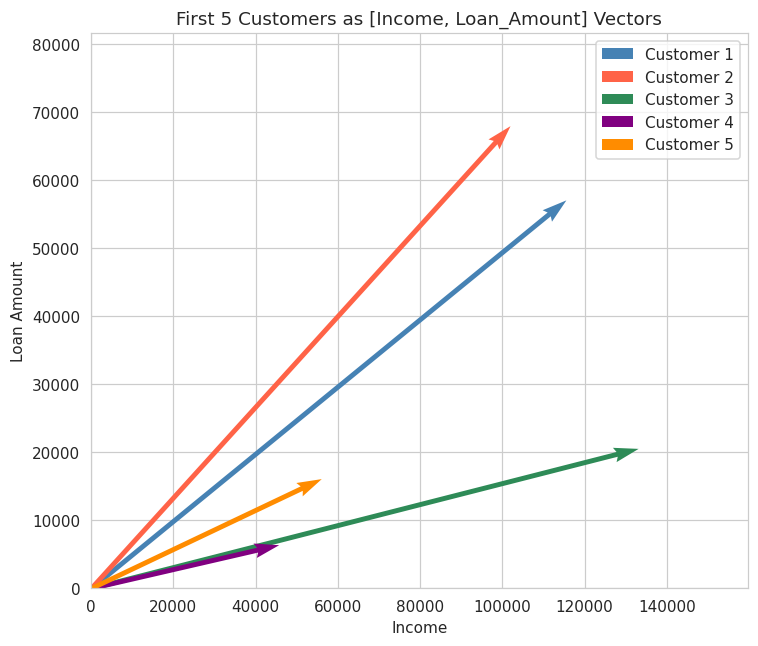

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = ['steelblue', 'tomato', 'seagreen', 'purple', 'darkorange']
for i, v in enumerate(vectors):
    ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color=colors[i], label=f'Customer {i+1}')

ax.set_xlim(0, vectors[:, 0].max() * 1.2)
ax.set_ylim(0, vectors[:, 1].max() * 1.2)
ax.set_xlabel('Income')
ax.set_ylabel('Loan Amount')
ax.set_title('First 5 Customers as [Income, Loan_Amount] Vectors')
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation:** Each arrow is one customer's financial vector, starting from the origin. Arrows pointing in a similar direction represent customers with a similar income-to-loan ratio, while arrows of different lengths simply reflect different overall financial scale — exactly the distinction the angle and norm calculations above were designed to separate.

## 📋 Summary of Results & Key Insights

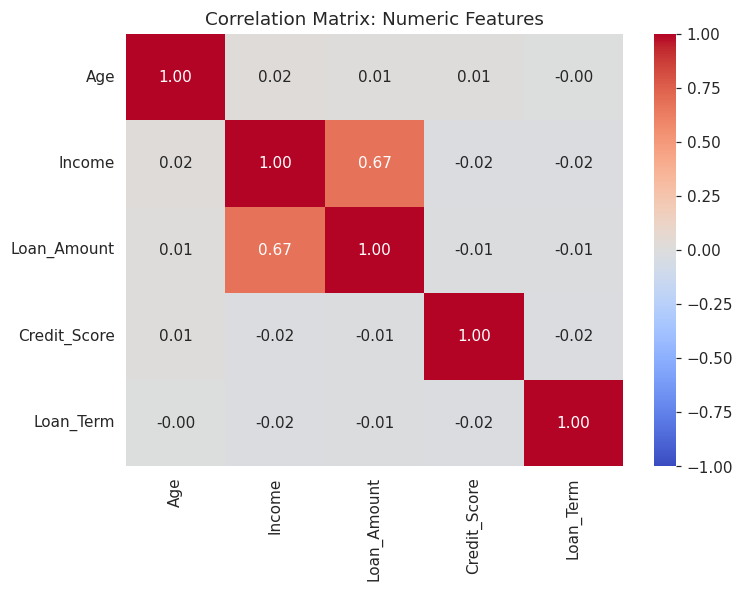

In [ ]:
numeric_cols = ['Age', 'Income', 'Loan_Amount', 'Credit_Score', 'Loan_Term']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix: Numeric Features')
plt.tight_layout()
plt.show()


* In this final cell, I built a correlation matrix across all the numeric columns and visualized it as a heatmap.
* Each cell shows how strongly two variables move together, from -1 (opposite directions) to +1 (perfectly together).
* This ties back to the eigenvalues/eigenvectors theory answer from Part A — this exact matrix is what a real PCA would decompose to find the dominant patterns in the data.
* It's a natural way to close the analysis, summarizing how all the numeric fields relate to each other in one view.

In [ ]:
summary = pd.DataFrame([
    {"Task": "Central Tendency", "Metric": "Income Mean vs Median", "Result": f"{income_mean:,.0f} vs {income_median:,.0f}", "Insight": "Mean > Median confirms right-skewed income"},
    {"Task": "Dispersion", "Metric": "Loan_Amount Std Dev", "Result": f"{loan_std:,.0f}", "Insight": "Wide spread in loan sizes across customers"},
    {"Task": "Probability", "Metric": "P(Default)", "Result": f"{p_default*100:.1f}%", "Insight": "Baseline default rate across all customers"},
    {"Task": "Conditional Probability", "Metric": "P(Default | Credit_Score<600)", "Result": f"{p_default_given_low_credit*100:.1f}%", "Insight": "Low credit score customers default far more often"},
    {"Task": "Distribution Fit", "Metric": "Credit_Score vs Normal", "Result": "Close to Gaussian", "Insight": "Credit scoring is designed to be roughly Normal"},
    {"Task": "Skew/Kurtosis", "Metric": "Loan_Amount", "Result": f"Skew={loan_skew:.2f}, Kurtosis={loan_kurt:.2f}", "Insight": "Loan sizes are right-skewed with a long tail"},
    {"Task": "Normality Check", "Metric": "Income Q-Q Plot", "Result": "Deviates in upper tail", "Insight": "Income is not Normally distributed"},
    {"Task": "Linear Algebra", "Metric": "Customer Vector Angle", "Result": f"{angle_deg:.1f} degrees", "Insight": "Quantifies similarity of income-to-loan ratio"},
])
summary


,Task,Metric,Result,Insight
0,Central Tendency,Income Mean vs Median,"53,749 vs 48,352",Mean > Median confirms right-skewed income
1,Dispersion,Loan_Amount Std Dev,"15,261",Wide spread in loan sizes across customers
2,Probability,P(Default),17.2%,Baseline default rate across all customers
3,Conditional Probability,P(Default | Credit_Score<600),34.3%,Low credit score customers default far more often
4,Distribution Fit,Credit_Score vs Normal,Close to Gaussian,Credit scoring is designed to be roughly Normal
5,Skew/Kurtosis,Loan_Amount,"Skew=2.16, Kurtosis=8.64",Loan sizes are right-skewed with a long tail
6,Normality Check,Income Q-Q Plot,Deviates in upper tail,Income is not Normally distributed
7,Linear Algebra,Customer Vector Angle,7.4 degrees,Quantifies similarity of income-to-loan ratio


* This final cell doesn't calculate anything new — it just gathers the key result from every task into one table.
* Each row pairs a method with its result and a one-line, plain-English insight.
* Reading down the "Insight" column gives a fast, complete picture of what the whole analysis found, without re-running any code.
* Overall, the results show that credit score is the strongest signal for default risk, and that both income and loan amount are right-skewed rather than Normally distributed — both important facts for any bank building a risk model on this data.